
# Urban Observation Gap Dashboard

이 노트북은 20개 개별 인사이트를 하나의 통합 프레임으로 묶기 위한 대시보드형 분석 코드입니다.

핵심 컨셉:
- 보이는 도시: 지하철 데이터가 보여주는 도시
- 실제 도시: 생활이동 데이터가 보여주는 도시
- 관측 격차: 두 도시 사이의 차이
- 정책 우선순위: gap이 크고, 생활 수요가 높고, 보완 가능성이 큰 지역

생성되는 주요 결과:
1. Urban Observation Gap Score
2. Station Risk / Opportunity Tier
3. Multi-layer Dashboard HTML
4. Sankey Observation System
5. Policy Priority Matrix
6. Station Profile Cards
7. Integrated Index CSV


In [1]:

# ============================================================
# 0. SAFE INSTALL
# ============================================================

import sys
import subprocess

packages = [
    "pandas",
    "numpy",
    "plotly",
    "kaleido"
]

for p in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p])
        print("[OK]", p)
    except Exception as e:
        print("[INSTALL SKIP]", p, e)


[OK] pandas
[OK] numpy
[OK] plotly
[OK] kaleido


In [2]:

# ============================================================
# 1. IMPORT & PATH
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

BASE_DIR = r"C:\Users\82108\Desktop\새 폴더 (8)"

INPUT_PATH = os.path.join(
    BASE_DIR,
    "diverse_mobility_subway_analysis_filtered",
    "08_compare_subway_total_filtered.csv"
)

MAPPING_PATH = os.path.join(
    BASE_DIR,
    "station_mapping_final",
    "cell_to_nearest_station_VALID_5km_MASTER_ID_FILTERED.csv"
)

SAVE_DIR = os.path.join(
    BASE_DIR,
    "URBAN_OBSERVATION_GAP_DASHBOARD"
)

HTML_DIR = os.path.join(SAVE_DIR, "html")
PNG_DIR = os.path.join(SAVE_DIR, "png")
CSV_DIR = os.path.join(SAVE_DIR, "csv")

for d in [SAVE_DIR, HTML_DIR, PNG_DIR, CSV_DIR]:
    os.makedirs(d, exist_ok=True)

print("[INPUT_PATH]", INPUT_PATH)
print("[MAPPING_PATH]", MAPPING_PATH)
print("[SAVE_DIR]", SAVE_DIR)


[INPUT_PATH] C:\Users\82108\Desktop\새 폴더 (8)\diverse_mobility_subway_analysis_filtered\08_compare_subway_total_filtered.csv
[MAPPING_PATH] C:\Users\82108\Desktop\새 폴더 (8)\station_mapping_final\cell_to_nearest_station_VALID_5km_MASTER_ID_FILTERED.csv
[SAVE_DIR] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD


In [3]:

# ============================================================
# 2. LOAD DATA
# ============================================================

def read_csv_safe(path):
    for enc in ["utf-8-sig", "cp949", "euc-kr", "utf-8"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            df.columns = df.columns.astype(str).str.strip().str.replace("\ufeff", "", regex=False)
            return df
        except UnicodeDecodeError:
            pass
    return pd.read_csv(path)

df = read_csv_safe(INPUT_PATH)
mapping = read_csv_safe(MAPPING_PATH)

map_agg = (
    mapping
    .groupby("MASTER_STATION_ID", as_index=False)
    .agg(
        station_lat=("station_lat", "mean"),
        station_lon=("station_lon", "mean"),
        mapped_cell_count_from_mapping=("CELL_ID", "nunique"),
        mean_mapping_distance_m=("nearest_station_distance_m", "mean"),
        mean_accessibility=("station_accessibility_score", "mean")
    )
)

df = df.merge(map_agg, on="MASTER_STATION_ID", how="left")

if "cluster" not in df.columns:
    df["cluster"] = -1

df = df.dropna(subset=["station_lat", "station_lon"]).copy()

print("[DF]", df.shape)
df.head()


[DF] (327, 53)


,MASTER_STATION_ID,nearest_station,nearest_line,mapped_cell_count,active_cell_count,surrounding_total_flow,surrounding_outflow,surrounding_inflow,surrounding_netflow,mean_cell_flow,...,outer_hidden_demand_score,diverse_living_area_score,directional_mismatch_score,station_type,station_lat,station_lon,mapped_cell_count_from_mapping,mean_mapping_distance_m,mean_accessibility,cluster
0,2519,까치산,5호선,57,57,3.689355e+08,1.854868e+08,1.834487e+08,-2038111.28,6.472553e+06,...,0.124168,0.342225,0.035016,diverse_living_area_hidden,37.531768,126.846683,57,913.964191,0.001606,-1
1,2824,단대오거리,8호선,95,67,2.698392e+08,1.354319e+08,1.344073e+08,-1024670.79,2.840412e+06,...,0.287259,0.446577,0.015662,diverse_living_area_hidden,37.445210,127.156866,95,1664.213689,0.001048,-1
2,2561,마천,5호선,312,105,2.534684e+08,1.279869e+08,1.254814e+08,-2505534.43,8.123986e+05,...,0.317050,0.336635,0.010145,diverse_living_area_hidden,37.494990,127.152781,312,2511.516994,0.000627,-1
3,249,신정네거리,2호선,60,57,2.391256e+08,1.203076e+08,1.188180e+08,-1489597.98,3.985426e+06,...,0.208845,0.289594,0.000988,diverse_living_area_hidden,37.520074,126.852912,60,1016.655234,0.001523,-1
4,2716,중계,7호선,33,32,2.431422e+08,1.219065e+08,1.212357e+08,-670840.33,7.367945e+06,...,0.090448,0.196988,0.032799,diverse_living_area_hidden,37.644583,127.064303,33,704.966065,0.002264,-1


In [4]:

# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

EPS = 1e-9

def norm(s):
    s = pd.to_numeric(s, errors="coerce").fillna(0).astype(float)
    mn, mx = s.min(), s.max()
    if mx - mn < EPS:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)

def row_entropy(data, cols, normalize=True):
    arr = data[cols].astype(float).clip(lower=0).values
    p = arr / (arr.sum(axis=1, keepdims=True) + EPS)
    e = -(p * np.log(p + EPS)).sum(axis=1)
    if normalize and len(cols) > 1:
        e = e / np.log(len(cols))
    return pd.Series(e, index=data.index)

def save_plotly(fig, name):
    html_path = os.path.join(HTML_DIR, f"{name}.html")
    png_path = os.path.join(PNG_DIR, f"{name}.png")
    fig.write_html(html_path)
    try:
        fig.write_image(png_path, scale=2)
    except Exception as e:
        print("[PNG FAIL]", name, e)
    print("[SAVED]", html_path)
    return html_path

def save_csv(data, name):
    path = os.path.join(CSV_DIR, f"{name}.csv")
    data.to_csv(path, index=False, encoding="utf-8-sig")
    print("[CSV]", path)
    return path

period_cols = ["morning_peak_flow", "daytime_flow", "evening_peak_flow", "night_flow"]

for c in period_cols:
    if c not in df.columns:
        df[c] = 0

df["E_time"] = row_entropy(df, period_cols)
df["source_gap"] = (df["mobility_norm"] - df["subway_norm"]).abs()
df["direction_gap"] = (df["station_directional_imbalance"] - df["subway_directional_imbalance"]).abs()
df["night_share"] = df["night_flow"] / (df[period_cols].sum(axis=1) + EPS)

print("[HELPERS READY]")


[HELPERS READY]



## 1. Urban Observation Gap Score 생성

이 점수는 단순 hidden demand가 아니라,  
생활이동·지하철·방향성·거리 확산·시간 다양성을 통합해  
“도시가 얼마나 잘못 관측되고 있는가”를 나타내는 지표입니다.


In [5]:

# ============================================================
# 4. INTEGRATED SCORES
# ============================================================

df["UOG_observation_gap"] = (
    0.30 * norm(df["source_gap"]) +
    0.25 * norm(df["hidden_demand_score"]) +
    0.15 * norm(df["mobility_minus_subway_gap"].abs()) +
    0.15 * norm(df["directional_mismatch_score"]) +
    0.15 * norm(df["mean_mapping_distance_m"])
)

df["UOG_lived_city_strength"] = (
    0.40 * norm(df["surrounding_total_flow"]) +
    0.25 * norm(df["mean_cell_flow"]) +
    0.20 * norm(df["active_cell_ratio"]) +
    0.15 * norm(df["mapped_cell_count"])
)

df["UOG_transit_visibility"] = (
    0.55 * norm(df["subway_total_activity"]) +
    0.25 * norm(df["subway_norm"]) +
    0.20 * norm(df["subway_record_count"])
)

df["UOG_spatial_diffusion"] = (
    0.40 * norm(df["outer_1km_plus_share"]) +
    0.30 * norm(df["distance_band_entropy"]) +
    0.30 * norm(df["mean_distance_m"])
)

df["UOG_temporal_complexity"] = (
    0.55 * norm(df["E_time"]) +
    0.25 * norm(df["period_entropy"]) +
    0.20 * norm(df["night_share"])
)

df["UOG_policy_priority"] = (
    0.35 * df["UOG_observation_gap"] +
    0.25 * df["UOG_lived_city_strength"] +
    0.15 * df["UOG_spatial_diffusion"] +
    0.15 * df["UOG_temporal_complexity"] +
    0.10 * (1 - df["UOG_transit_visibility"])
)

# Tiering
q1 = df["UOG_policy_priority"].quantile(0.75)
q2 = df["UOG_policy_priority"].quantile(0.50)
q3 = df["UOG_policy_priority"].quantile(0.25)

df["UOG_tier"] = "D. 관찰 유지"
df.loc[df["UOG_policy_priority"] >= q3, "UOG_tier"] = "C. 모니터링"
df.loc[df["UOG_policy_priority"] >= q2, "UOG_tier"] = "B. 정책 검토"
df.loc[df["UOG_policy_priority"] >= q1, "UOG_tier"] = "A. 우선 개입"

df["UOG_type"] = "일반 관측권"
df.loc[(df["UOG_observation_gap"] >= df["UOG_observation_gap"].quantile(0.75)) & 
       (df["UOG_lived_city_strength"] >= df["UOG_lived_city_strength"].quantile(0.50)), "UOG_type"] = "숨은 생활권"
df.loc[(df["directional_mismatch_score"] >= df["directional_mismatch_score"].quantile(0.90)), "UOG_type"] = "방향 충돌권"
df.loc[(df["UOG_spatial_diffusion"] >= df["UOG_spatial_diffusion"].quantile(0.80)), "UOG_type"] = "광역 의존권"
df.loc[(df["night_share"] >= df["night_share"].quantile(0.80)) & 
       (df["UOG_temporal_complexity"] >= df["UOG_temporal_complexity"].quantile(0.50)), "UOG_type"] = "야간 생활권"

top = df.sort_values("UOG_policy_priority", ascending=False).head(30)
display(top[[
    "nearest_station", "nearest_line", "UOG_policy_priority", "UOG_tier", "UOG_type",
    "UOG_observation_gap", "UOG_lived_city_strength", "UOG_transit_visibility",
    "UOG_spatial_diffusion", "UOG_temporal_complexity"
]])

save_csv(df, "urban_observation_gap_full_scores")
save_csv(top, "urban_observation_gap_top30")


,nearest_station,nearest_line,UOG_policy_priority,UOG_tier,UOG_type,UOG_observation_gap,UOG_lived_city_strength,UOG_transit_visibility,UOG_spatial_diffusion,UOG_temporal_complexity
2,마천,5호선,0.671893,A. 우선 개입,광역 의존권,0.780360,0.457819,0.253962,0.818959,0.579101
1,단대오거리,8호선,0.657882,A. 우선 개입,광역 의존권,0.745629,0.475692,0.287512,0.694491,0.683775
0,까치산,5호선,0.641610,A. 우선 개입,광역 의존권,0.769294,0.646484,0.455887,0.450129,0.592038
9,남한산성입구(성남법원.검찰청),8호선,0.599046,A. 우선 개입,광역 의존권,0.640651,0.386211,0.303663,0.803178,0.587699
3,신정네거리,2호선,0.585841,A. 우선 개입,광역 의존권,0.627808,0.486460,0.281030,0.557273,0.593367
14,부천시청,7호선,0.571553,A. 우선 개입,광역 의존권,0.550721,0.400752,0.164736,0.681870,0.618706
8,가양,9호선,0.556822,A. 우선 개입,광역 의존권,0.642072,0.405110,0.292123,0.486083,0.580794
6,홍제,3호선,0.553494,A. 우선 개입,광역 의존권,0.562905,0.471877,0.356605,0.606329,0.554793
16,북한산보국문,우이신설선,0.550326,A. 우선 개입,광역 의존권,0.645389,0.333646,0.205207,0.550928,0.526064
7,거여,5호선,0.550318,A. 우선 개입,광역 의존권,0.551567,0.445257,0.275452,0.596176,0.560492


[CSV] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD\csv\urban_observation_gap_full_scores.csv
[CSV] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD\csv\urban_observation_gap_top30.csv


'C:\\Users\\82108\\Desktop\\새 폴더 (8)\\URBAN_OBSERVATION_GAP_DASHBOARD\\csv\\urban_observation_gap_top30.csv'


## 2. Main Dashboard

한 화면에서 다음을 동시에 봅니다.

- 좌상단: 보이는 도시 vs 실제 도시 비교
- 우상단: 정책 우선순위 ranking
- 좌하단: 관측 gap × 생활 강도 matrix
- 우하단: 도시 관측 레이어 구성


In [6]:

# ============================================================
# 5. MAIN DASHBOARD
# ============================================================

top30 = df.sort_values("UOG_policy_priority", ascending=False).head(30).copy()
bar_df = top30.sort_values("UOG_policy_priority")

layer_mean = pd.DataFrame({
    "layer": [
        "관측 gap",
        "실제 생활강도",
        "지하철 가시성",
        "공간 확산성",
        "시간 복합성"
    ],
    "score": [
        df["UOG_observation_gap"].mean(),
        df["UOG_lived_city_strength"].mean(),
        df["UOG_transit_visibility"].mean(),
        df["UOG_spatial_diffusion"].mean(),
        df["UOG_temporal_complexity"].mean()
    ]
})

fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "scatter"}, {"type": "bar"}],
        [{"type": "scatter"}, {"type": "domain"}]
    ],
    subplot_titles=(
        "Observed City vs Lived City",
        "정책 우선순위 Top 30",
        "Observation Gap × Lived City Strength",
        "Urban Observation Layers"
    )
)

# 1. observed vs lived
fig.add_trace(
    go.Scatter(
        x=df["UOG_transit_visibility"],
        y=df["UOG_lived_city_strength"],
        mode="markers",
        marker=dict(
            size=8 + 28*norm(df["UOG_policy_priority"]),
            color=df["UOG_observation_gap"],
            colorscale="Turbo",
            showscale=True,
            colorbar=dict(title="Gap")
        ),
        text=df["nearest_station"],
        hovertemplate="%{text}<br>Transit visibility=%{x:.3f}<br>Lived strength=%{y:.3f}<extra></extra>",
        name="stations"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=[0,1], y=[0,1],
        mode="lines",
        line=dict(color="gray", dash="dash"),
        name="balanced"
    ),
    row=1, col=1
)

# 2. ranking
fig.add_trace(
    go.Bar(
        x=bar_df["UOG_policy_priority"],
        y=bar_df["nearest_station"],
        orientation="h",
        marker=dict(color=bar_df["UOG_policy_priority"], colorscale="Inferno"),
        name="policy priority"
    ),
    row=1, col=2
)

# 3. matrix
fig.add_trace(
    go.Scatter(
        x=df["UOG_observation_gap"],
        y=df["UOG_lived_city_strength"],
        mode="markers",
        marker=dict(
            size=8 + 25*norm(df["UOG_spatial_diffusion"]),
            color=df["UOG_temporal_complexity"],
            colorscale="Viridis",
            showscale=False
        ),
        text=df["nearest_station"],
        hovertemplate="%{text}<br>Gap=%{x:.3f}<br>Lived=%{y:.3f}<extra></extra>",
        name="matrix"
    ),
    row=2, col=1
)

# 4. layer pie
fig.add_trace(
    go.Pie(
        labels=layer_mean["layer"],
        values=layer_mean["score"],
        hole=0.45,
        name="layers"
    ),
    row=2, col=2
)

fig.update_layout(
    height=1050,
    title="Urban Observation Gap Dashboard: 보이는 도시와 실제 도시의 격차",
    showlegend=False
)

fig.update_xaxes(title_text="Transit visibility", row=1, col=1)
fig.update_yaxes(title_text="Lived city strength", row=1, col=1)
fig.update_xaxes(title_text="Policy priority score", row=1, col=2)
fig.update_xaxes(title_text="Observation gap", row=2, col=1)
fig.update_yaxes(title_text="Lived city strength", row=2, col=1)

save_plotly(fig, "01_main_urban_observation_gap_dashboard")
fig.show()


[PNG FAIL] 01_main_urban_observation_gap_dashboard 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

[SAVED] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD\html\01_main_urban_observation_gap_dashboard.html



## 3. Sankey: 도시 관측 시스템

생활이동 → 관측 상태 → 정책 개입 유형으로 이어지는 흐름을 Sankey로 보여줍니다.  
이 그림은 발표에서 “우리 분석이 무엇을 찾아냈는가”를 설명하는 핵심 요약용입니다.


In [7]:

# ============================================================
# 6. SANKEY OBSERVATION SYSTEM
# ============================================================

sankey_df = df.copy()

# source category
sankey_df["source_state"] = pd.cut(
    sankey_df["UOG_lived_city_strength"],
    bins=[-0.01, 0.33, 0.66, 1.01],
    labels=["낮은 생활이동", "중간 생활이동", "높은 생활이동"]
)

sankey_df["observation_state"] = pd.cut(
    sankey_df["UOG_observation_gap"],
    bins=[-0.01, 0.33, 0.66, 1.01],
    labels=["잘 관측됨", "부분 관측", "과소 관측"]
)

sankey_df["policy_state"] = sankey_df["UOG_tier"]

# aggregate flows
flow1 = sankey_df.groupby(["source_state", "observation_state"]).size().reset_index(name="count")
flow2 = sankey_df.groupby(["observation_state", "policy_state"]).size().reset_index(name="count")

labels = (
    list(flow1["source_state"].astype(str).unique()) +
    list(flow1["observation_state"].astype(str).unique()) +
    list(flow2["policy_state"].astype(str).unique())
)
labels = list(dict.fromkeys(labels))
label_idx = {l:i for i,l in enumerate(labels)}

sources = []
targets = []
values = []

for _, r in flow1.iterrows():
    sources.append(label_idx[str(r["source_state"])])
    targets.append(label_idx[str(r["observation_state"])])
    values.append(int(r["count"]))

for _, r in flow2.iterrows():
    sources.append(label_idx[str(r["observation_state"])])
    targets.append(label_idx[str(r["policy_state"])])
    values.append(int(r["count"]))

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=18,
        thickness=18,
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig.update_layout(
    title="Urban Observation System Sankey: 생활이동 → 관측상태 → 정책개입",
    height=760
)

save_plotly(fig, "02_sankey_observation_system")
fig.show()


[PNG FAIL] 02_sankey_observation_system 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

[SAVED] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD\html\02_sankey_observation_system.html



## 4. Policy Priority Matrix

x축은 지하철 관측 부족, y축은 실제 생활 수요입니다.  
오른쪽 위에 위치한 역은 “사람은 많이 움직이는데 교통 관측은 약한 지역”입니다.


In [8]:

# ============================================================
# 7. POLICY PRIORITY MATRIX
# ============================================================

df["transit_deficit"] = 1 - df["UOG_transit_visibility"]

fig = px.scatter(
    df,
    x="transit_deficit",
    y="UOG_lived_city_strength",
    size="UOG_policy_priority",
    color="UOG_type",
    hover_name="nearest_station",
    hover_data=[
        "nearest_line",
        "UOG_tier",
        "UOG_observation_gap",
        "hidden_demand_score",
        "mobility_minus_subway_gap"
    ],
    height=850,
    title="Policy Priority Matrix: 교통 부족 × 실제 생활 수요"
)

# quadrant lines
fig.add_vline(x=df["transit_deficit"].median(), line_dash="dash", line_color="gray")
fig.add_hline(y=df["UOG_lived_city_strength"].median(), line_dash="dash", line_color="gray")

fig.add_annotation(
    x=0.85, y=0.95,
    text="우선 개입 후보<br>생활수요 높음 + 교통 관측 낮음",
    showarrow=False,
    bgcolor="rgba(255,255,255,0.8)"
)

save_plotly(fig, "03_policy_priority_matrix")
fig.show()


[PNG FAIL] 03_policy_priority_matrix 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

[SAVED] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD\html\03_policy_priority_matrix.html



## 5. Dual Reality Map

같은 서울을 두 개의 현실로 봅니다.

- 왼쪽: 지하철이 보는 도시
- 오른쪽: 생활이동이 보여주는 도시


In [9]:

# ============================================================
# 8. DUAL REALITY MAP
# ============================================================

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Subway City: 지하철이 보는 도시", "Lived City: 생활이동이 보여주는 도시"),
    specs=[[{"type": "scattermapbox"}, {"type": "scattermapbox"}]]
)

fig.add_trace(
    go.Scattermapbox(
        lat=df["station_lat"],
        lon=df["station_lon"],
        mode="markers",
        marker=dict(
            size=6 + 24*norm(df["subway_norm"]),
            color=df["subway_norm"],
            colorscale="Blues",
            opacity=0.75,
            showscale=False
        ),
        text=df["nearest_station"],
        name="Subway City",
        hovertemplate="%{text}<br>Subway norm=%{marker.color:.3f}<extra></extra>"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scattermapbox(
        lat=df["station_lat"],
        lon=df["station_lon"],
        mode="markers",
        marker=dict(
            size=6 + 24*norm(df["mobility_norm"]),
            color=df["mobility_norm"],
            colorscale="Magma",
            opacity=0.75,
            showscale=False
        ),
        text=df["nearest_station"],
        name="Lived City",
        hovertemplate="%{text}<br>Mobility norm=%{marker.color:.3f}<extra></extra>"
    ),
    row=1, col=2
)

center = dict(lat=float(df["station_lat"].mean()), lon=float(df["station_lon"].mean()))

fig.update_layout(
    mapbox=dict(style="carto-darkmatter", zoom=9.7, center=center),
    mapbox2=dict(style="carto-darkmatter", zoom=9.7, center=center),
    height=760,
    title="Dual Reality Map: 보이는 도시와 실제 도시"
)

save_plotly(fig, "04_dual_reality_map")
fig.show()


[PNG FAIL] 04_dual_reality_map 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

[SAVED] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD\html\04_dual_reality_map.html



## 6. Station Profile Cards

정책 우선순위 상위 역을 카드처럼 보여줍니다.  
각 역이 왜 중요한지 레이어별 점수로 설명합니다.


In [10]:

# ============================================================
# 9. STATION PROFILE CARDS
# ============================================================

profile = df.sort_values("UOG_policy_priority", ascending=False).head(12).copy()

card_cols = [
    "UOG_observation_gap",
    "UOG_lived_city_strength",
    "UOG_transit_visibility",
    "UOG_spatial_diffusion",
    "UOG_temporal_complexity"
]

fig = make_subplots(
    rows=3, cols=4,
    specs=[[{"type":"polar"}]*4,
           [{"type":"polar"}]*4,
           [{"type":"polar"}]*4],
    subplot_titles=profile["nearest_station"].tolist()
)

for idx, (_, r) in enumerate(profile.iterrows()):
    row = idx // 4 + 1
    col = idx % 4 + 1
    vals = [r[c] for c in card_cols]
    vals = vals + [vals[0]]
    theta = ["관측 gap", "생활강도", "지하철가시성", "공간확산", "시간복합", "관측 gap"]

    fig.add_trace(
        go.Scatterpolar(
            r=vals,
            theta=theta,
            fill="toself",
            name=r["nearest_station"],
            opacity=0.75
        ),
        row=row, col=col
    )

fig.update_layout(
    height=1050,
    title="Station Profile Cards: 정책 우선순위 상위 12개 역의 관측 레이어"
)

save_plotly(fig, "05_station_profile_cards")
fig.show()


[PNG FAIL] 05_station_profile_cards 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

[SAVED] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD\html\05_station_profile_cards.html



## 7. Urban Observation Stack

도시를 하나의 관측 시스템으로 보고,  
각 역이 어떤 레이어에서 강한지 stacked bar로 보여줍니다.


In [11]:

# ============================================================
# 10. URBAN OBSERVATION STACK
# ============================================================

stack = df.sort_values("UOG_policy_priority", ascending=False).head(20).copy()

fig = go.Figure()

layer_map = {
    "관측 gap": "UOG_observation_gap",
    "실제 생활강도": "UOG_lived_city_strength",
    "지하철 가시성": "UOG_transit_visibility",
    "공간 확산성": "UOG_spatial_diffusion",
    "시간 복합성": "UOG_temporal_complexity"
}

for label, col in layer_map.items():
    fig.add_trace(go.Bar(
        x=stack["nearest_station"],
        y=stack[col],
        name=label
    ))

fig.update_layout(
    barmode="stack",
    height=820,
    title="Urban Observation Stack: 상위 20개 역의 다층 관측 구조",
    xaxis_tickangle=-45
)

save_plotly(fig, "06_urban_observation_stack")
fig.show()


[PNG FAIL] 06_urban_observation_stack 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

[SAVED] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD\html\06_urban_observation_stack.html



## 8. Final Export

최종 지표와 tier를 CSV로 저장합니다.


In [12]:

# ============================================================
# 11. FINAL EXPORT & INDEX
# ============================================================

final_cols = [
    "MASTER_STATION_ID", "nearest_station", "nearest_line", "station_type",
    "station_lat", "station_lon",
    "UOG_policy_priority", "UOG_tier", "UOG_type",
    "UOG_observation_gap",
    "UOG_lived_city_strength",
    "UOG_transit_visibility",
    "UOG_spatial_diffusion",
    "UOG_temporal_complexity",
    "hidden_demand_score",
    "mobility_minus_subway_gap",
    "directional_mismatch_score",
    "outer_hidden_demand_score",
    "diverse_living_area_score"
]

final_df = df[final_cols].copy()
save_csv(final_df, "final_urban_observation_gap_index")

# index html
html_files = sorted([f for f in os.listdir(HTML_DIR) if f.endswith(".html")])
index_path = os.path.join(SAVE_DIR, "OPEN_ME_INDEX.html")

with open(index_path, "w", encoding="utf-8") as f:
    f.write("""
    <html>
    <head><meta charset="utf-8"><title>Urban Observation Gap Dashboard</title>
    <style>
    body { background:#111; color:#eee; font-family:Arial; padding:28px; }
    .card { background:#1b1b1b; border:1px solid #333; border-radius:10px; padding:14px; margin:10px 0; }
    a { color:#8fd3ff; text-decoration:none; font-size:16px; }
    </style>
    </head>
    <body>
    <h1>Urban Observation Gap Dashboard</h1>
    <p>보이는 도시와 실제 도시의 차이를 통합적으로 분석한 대시보드입니다.</p>
    """)
    for h in html_files:
        f.write(f'<div class="card"><a href="html/{h}" target="_blank">{h}</a></div>')
    f.write("</body></html>")

print("DONE")
print("[SAVE_DIR]", SAVE_DIR)
print("[OPEN]", index_path)


[CSV] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD\csv\final_urban_observation_gap_index.csv
DONE
[SAVE_DIR] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD
[OPEN] C:\Users\82108\Desktop\새 폴더 (8)\URBAN_OBSERVATION_GAP_DASHBOARD\OPEN_ME_INDEX.html


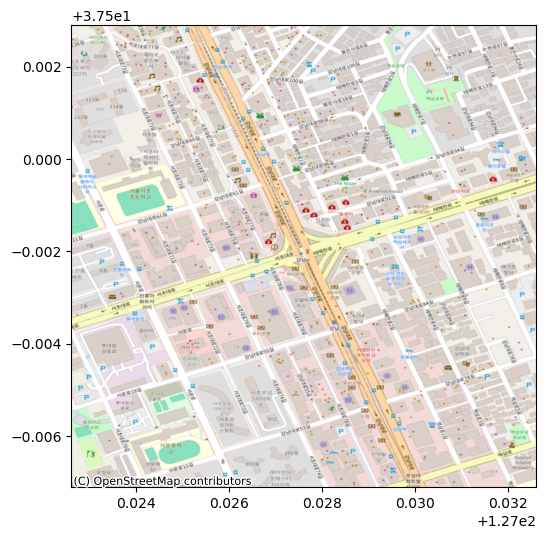

In [15]:
import contextily as ctx
import matplotlib.pyplot as plt

# 서울 강남역 좌표
lon, lat = 127.0276, 37.4979

fig, ax = plt.subplots(figsize=(6,6))

ax.set_xlim([lon-0.005, lon+0.005])
ax.set_ylim([lat-0.005, lat+0.005])

ctx.add_basemap(
    ax,
    crs="EPSG:4326",
    source=ctx.providers.OpenStreetMap.Mapnik
)

plt.savefig("gangnam.png")

In [14]:
pip install contextily

  Using cached contextily-1.7.0-py3-none-any.whl.metadata (3.1 kB)
   ---------------------------------------- 0.0/30.1 MB ? eta -:--:--
   -- ------------------------------------- 1.8/30.1 MB 9.5 MB/s eta 0:00:03
   ----- ---------------------------------- 3.9/30.1 MB 10.1 MB/s eta 0:00:03
   -------- ------------------------------- 6.3/30.1 MB 10.4 MB/s eta 0:00:03
   ----------- ---------------------------- 8.4/30.1 MB 10.4 MB/s eta 0:00:03
   -------------- ------------------------- 10.7/30.1 MB 10.5 MB/s eta 0:00:02
   ----------------- ---------------------- 12.8/30.1 MB 10.5 MB/s eta 0:00:02
   ------------------- -------------------- 14.7/30.1 MB 10.3 MB/s eta 0:00:02
   ---------------------- ----------------- 17.0/30.1 MB 10.4 MB/s eta 0:00:02
   ------------------------- -------------- 19.4/30.1 MB 10.5 MB/s eta 0:00:02
   ---------------------------- ----------- 21.5/30.1 MB 10.4 MB/s eta 0:00:01
   ------------------------------ --------- 22.8/30.1 MB 10.0 MB/s eta 0:00:01

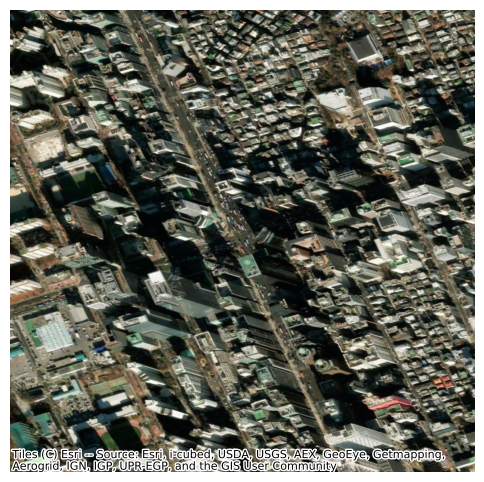

In [16]:
import matplotlib.pyplot as plt
import contextily as ctx

# 강남역 좌표
lon, lat = 127.0276, 37.4979

fig, ax = plt.subplots(figsize=(6,6))

# 범위 설정
ax.set_xlim([lon - 0.005, lon + 0.005])
ax.set_ylim([lat - 0.005, lat + 0.005])

# satellite tile 추가
ctx.add_basemap(
    ax,
    crs="EPSG:4326",
    source=ctx.providers.Esri.WorldImagery
)

ax.set_axis_off()

plt.savefig("gangnam_satellite.png", bbox_inches="tight", pad_inches=0)

In [ ]:
# pip install pandas geopandas shapely contextily matplotlib tqdm xyzservices

import os
import re
import pandas as pd
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import contextily as ctx
from tqdm import tqdm


INPUT_CSV = r"C:\Users\82108\Desktop\새 폴더 (8)\station_mapping_final\cell_to_nearest_station_VALID_5km_MASTER_ID_FILTERED.csv"

OUT_DIR = "station_tiles"
MAP_DIR = os.path.join(OUT_DIR, "map")
SAT_DIR = os.path.join(OUT_DIR, "satellite")
BBOX_OUT = os.path.join(OUT_DIR, "station_image_bboxes_wgs84.csv")

os.makedirs(MAP_DIR, exist_ok=True)
os.makedirs(SAT_DIR, exist_ok=True)


def safe_name(x):
    x = str(x)
    x = re.sub(r"[\\/:*?\"<>|]", "_", x)
    return x.strip()


def make_station_bboxes(input_csv, buffer_m=250):
    df = pd.read_csv(input_csv)

    station_boxes = (
        df.groupby(["MASTER_STATION_ID", "master_station_name"])
        .agg(
            min_x=("CELL_X", "min"),
            max_x=("CELL_X", "max"),
            min_y=("CELL_Y", "min"),
            max_y=("CELL_Y", "max"),
            station_lon=("station_lon", "first"),
            station_lat=("station_lat", "first"),
            n_cells=("CELL_ID", "count"),
        )
        .reset_index()
    )

    station_boxes["min_x"] -= buffer_m
    station_boxes["max_x"] += buffer_m
    station_boxes["min_y"] -= buffer_m
    station_boxes["max_y"] += buffer_m

    gdf = gpd.GeoDataFrame(
        station_boxes,
        geometry=[
            box(row.min_x, row.min_y, row.max_x, row.max_y)
            for _, row in station_boxes.iterrows()
        ],
        crs="EPSG:5179",
    )

    gdf_4326 = gdf.to_crs("EPSG:4326")
    bounds = gdf_4326.bounds

    gdf_4326["min_lon"] = bounds["minx"]
    gdf_4326["min_lat"] = bounds["miny"]
    gdf_4326["max_lon"] = bounds["maxx"]
    gdf_4326["max_lat"] = bounds["maxy"]

    os.makedirs(OUT_DIR, exist_ok=True)
    gdf_4326.drop(columns="geometry").to_csv(BBOX_OUT, index=False)

    return gdf_4326


def save_tile(row, source, out_path, zoom=16, dpi=150):
    min_lon = row["min_lon"]
    max_lon = row["max_lon"]
    min_lat = row["min_lat"]
    max_lat = row["max_lat"]

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_xlim(min_lon, max_lon)
    ax.set_ylim(min_lat, max_lat)

    ctx.add_basemap(
        ax,
        crs="EPSG:4326",
        source=source,
        zoom=zoom,
    )

    ax.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight", pad_inches=0)
    plt.close(fig)


def main():
    gdf = make_station_bboxes(INPUT_CSV, buffer_m=250)

    map_source = ctx.providers.OpenStreetMap.Mapnik
    satellite_source = ctx.providers.Esri.WorldImagery

    for _, row in tqdm(gdf.iterrows(), total=len(gdf)):
        sid = row["MASTER_STATION_ID"]
        name = safe_name(row["master_station_name"])

        filename = f"{sid}_{name}.png"

        map_path = os.path.join(MAP_DIR, filename)
        sat_path = os.path.join(SAT_DIR, filename)

        try:
            if not os.path.exists(map_path):
                save_tile(
                    row=row,
                    source=map_source,
                    out_path=map_path,
                    zoom=16,
                    dpi=150,
                )

            if not os.path.exists(sat_path):
                save_tile(
                    row=row,
                    source=satellite_source,
                    out_path=sat_path,
                    zoom=16,
                    dpi=150,
                )

        except Exception as e:
            print(f"Failed: {sid} {name} | {e}")

    print("Done.")
    print(f"Map images: {MAP_DIR}")
    print(f"Satellite images: {SAT_DIR}")
    print(f"BBox csv: {BBOX_OUT}")


if __name__ == "__main__":
    main()

  6%|▋         | 21/327 [03:07<54:39, 10.72s/it]

In [18]:
pip install geopandas



  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached shapely-2.1.2-cp313-cp313-win_amd64.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   --- ------------------------------------ 1.8/22.9 MB 9.8 MB/s eta 0:00:03
   ------- -------------------------------- 4.5/22.9 MB 10.6 MB/s eta 0:00:02
   ----------- ---------------------------- 6.6/22.9 MB 10.4 MB/s eta 0:00:02
   -------------- ------------------------- 8.1/22.9 MB 9.7 MB/s eta 0:00:02
   ----------------- ---------------------- 10.0/22.9 MB 9.5 MB/s eta 0:00:02
   -------------------- ------------------- 11.8/22.9 MB 9.4 MB/s eta 0:00:02
   ------------------------ --------------- 13.9/22.9 MB 9.4 MB/s eta 0:00:01
   -------------------------- ------------- 15.5/22.9 MB 9.2 MB/s eta 0:00:01
   ------------------------------ --------- 17.3/22.9 MB 9.1 MB/s eta 0:00:01
   -------------------------------- ------- 18.6/22.9 MB 8.9 MB/s eta 0:00:01
   ---------